# Type A — Static Drawdown Challenge Insurance

**What you're doing:** Buy a prop firm challenge, hedge your way through every phase, get funded, pocket the first payout.

**How the hedge works:**
1. Open matching trades on the prop firm account AND your personal broker (opposite directions)
2. Prop firm gains → personal broker loses the same amount (that's the hedge cost)
3. You always pass. The hedge guarantees it.
4. Once funded, your first payout needs to cover everything you spent

**What "Static Drawdown" means:** The max drawdown limit is fixed from your starting balance. A $100k account with 10% max drawdown has a floor at $90k — it stays there no matter how much profit you make. This keeps the hedge simple: the position size doesn't change within a phase.

## The Numbers

$$\text{Funded Payout} = \text{Account Size} \times \text{Funded Target \%} \times \text{Profit Split \%}$$

$$\text{Total Cost} = \text{Challenge Fee} + \text{Activation Fee} + \text{All Hedge Losses}$$

$$\text{EV} = \text{Funded Payout} - \text{Total Cost}$$

> Positive EV = the payout exceeds the cost. Negative EV = the hedge costs more than you'd earn.

## Setup

In [7]:
import sqlite3, json, os, math, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DB_PATH = os.path.join(
    os.environ.get("WORKSPACE_ROOT", r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"),
    "Business", "STRATEGY", "resources", "PropFirmData", "propmatch_model_input.db"
)
EXEC_PATH = os.path.abspath(os.path.join(os.path.dirname(DB_PATH), "..", "..", "executions"))
if EXEC_PATH not in sys.path:
    sys.path.insert(0, EXEC_PATH)

# ── Assumptions you can tweak ──
FUNDED_TARGET = 0.08   # 8% funded profit target
SPREAD_COST   = 0.0003 # ~3 pips per trade
LEVERAGE      = 100    # 1:100 on personal broker

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

print(f"Type A notebook ready.")
print(f"Funded target: {FUNDED_TARGET*100:.0f}%  |  Spread: {SPREAD_COST*100:.2f}%  |  Leverage: 1:{LEVERAGE}")

Type A notebook ready.
Funded target: 8%  |  Spread: 0.03%  |  Leverage: 1:100


## Load Static Drawdown Challenges

In [8]:
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row
rows = conn.execute("SELECT * FROM v_model_inputs WHERE survival_model_class = 'challenge_static' ORDER BY account_size, fee_assumed").fetchall()
conn.close()

challenges = []
for row in rows:
    d = dict(row)
    pt = d.pop("profit_targets", None)
    if isinstance(pt, str):
        try:
            d["profit_targets"] = json.loads(pt)
        except (json.JSONDecodeError, TypeError):
            d["profit_targets"] = []
    else:
        d["profit_targets"] = pt or []
    challenges.append(d)

df_raw = pd.DataFrame(challenges)
print(f"Loaded {len(challenges)} static-drawdown challenges")
print(f"Firms: {df_raw['firm'].nunique()}")
print(f"Account sizes: {sorted(df_raw['account_size'].unique())}")
print(f"\nDrawdown details:")
print(f"  Static (balance-based): {(df_raw['drawdown_class']=='static').sum()}")
print(f"  EOD Balance:            {(df_raw['drawdown_class']=='eod_balance').sum()}")

Loaded 348 static-drawdown challenges
Firms: 32
Account sizes: [np.int64(2000), np.int64(2500), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(10000), np.int64(15000), np.int64(20000), np.int64(25000), np.int64(30000), np.int64(50000), np.int64(60000), np.int64(100000), np.int64(120000), np.int64(200000), np.int64(240000), np.int64(250000), np.int64(300000), np.int64(400000), np.int64(500000)]

Drawdown details:
  Static (balance-based): 151
  EOD Balance:            196


## Type A Math Engine

For each challenge phase, the hedge is sized to recover all your costs if the drawdown limit gets hit.

**Per phase:**
- **Hedge size** = Total costs so far ÷ Max drawdown %
- **When you pass** (you always do): the hedge loses = hedge size × phase target + spread costs
- **Cost stack grows**: new total = old cost + hedge loss

**Minimum trading days:** You must spread the gain across several days. With static drawdown the hedge size stays constant, but you pay spread costs on each day's round-trip.

- Daily target = Phase target ÷ Min trading days
- Spread cost = Hedge size × Spread % × 2 (buy + sell) × Number of days

In [9]:
from notebook_review_adjustment import build_review_adjusted_dataframe

def compute_type_a(challenge, funded_target=FUNDED_TARGET, spread_cost=SPREAD_COST):
    S = challenge['account_size']
    fee = challenge.get('fee_assumed') or challenge.get('fee_discounted') or 0
    activation_fee = challenge.get('activation_fee') or 0
    targets = challenge.get('profit_targets') or []
    steps = challenge.get('steps') or len(targets) or 2
    dd_pct = (challenge.get('max_drawdown_pct') or 10) / 100
    split = (challenge.get('profit_split_pct') or 80) / 100
    min_days = challenge.get('min_trading_days') or 1
    if isinstance(targets, str):
        targets = json.loads(targets)
    phase_targets = [t / 100 for t in targets] if targets else [0.08 / steps] * steps

    # Start with the challenge fee
    L = float(fee)
    phases = []

    for i in range(steps):
        target = phase_targets[i] if i < len(phase_targets) else phase_targets[-1]
        L_start = L

        # Hedge sized to recover all costs if drawdown hits
        hedge_size = L / dd_pct if dd_pct > 0 else 0

        # Trading days for spread calculation
        days = max(int(min_days), 1)
        daily_target = target / days

        # Static DD: hedge size is constant, spread cost scales with days
        spread_total = hedge_size * spread_cost * 2 * days
        hedge_loss = hedge_size * target + spread_total

        L = L + hedge_loss

        margin = hedge_size / LEVERAGE
        buffer = hedge_size * dd_pct * 1.5
        phases.append({
            'phase': i + 1, 'target_pct': round(target * 100, 2),
            'daily_target_pct': round(daily_target * 100, 4), 'trading_days': days,
            'cost_before': round(L_start, 2), 'hedge_size': round(hedge_size, 2),
            'spread_cost': round(spread_total, 2), 'hedge_loss': round(hedge_loss, 2),
            'cost_after': round(L, 2), 'capital_needed': round(margin + buffer, 2),
        })

    # Activation fee paid when you get funded
    L += float(activation_fee)
    total_cost = L
    funded_payout = S * funded_target * split
    EV = funded_payout - total_cost
    cap = max(ph['capital_needed'] for ph in phases) if phases else 0

    return {
        'firm': challenge.get('firm'), 'account_size': S,
        'fee': round(fee, 2), 'activation_fee': round(activation_fee, 2),
        'steps': steps, 'drawdown_class': challenge.get('drawdown_class'),
        'max_drawdown_pct': round(dd_pct * 100, 2),
        'profit_split_pct': round(split * 100, 1),
        'min_trading_days': int(min_days),
        'phases': phases, 'total_cost': round(total_cost, 2),
        'funded_payout': round(funded_payout, 2), 'EV': round(EV, 2),
        'breakeven_pct': round((total_cost / split / S) * 100, 2) if S > 0 else 0,
        'capital_needed': round(cap, 2),
        'capital_efficiency': round(EV / cap, 4) if cap > 0 else 0,
    }

results = [compute_type_a(c) for c in challenges]
df = build_review_adjusted_dataframe(
    results,
    challenges,
    raw_ev_col="EV",
    revenue_cols=["funded_payout"],
    capital_col="capital_needed",
    fee_col="fee",
)

pos_raw = (df['EV'] > 0).sum()
pos_adj = (df['EV_review_adj'] > 0).sum()
print(f"Positive EV (raw):        {pos_raw}/{len(df)} challenges")
print(f"Positive EV (review-adj): {pos_adj}/{len(df)} challenges")
print(f"Average EV (raw):         ${df['EV'].mean():,.2f}")
print(f"Average EV (review-adj):  ${df['EV_review_adj'].mean():,.2f}")
if pos_adj > 0:
    best = df.loc[df['EV_review_adj'].idxmax()]
    print(
        f"Best review-adj EV: {best['firm']} ${best['account_size']:,.0f} "
        f"→ ${best['EV_review_adj']:,.2f} (raw ${best['EV']:,.2f}, factor {best['review_factor']:.3f})"
    )

Positive EV (raw):        346/348 challenges
Positive EV (review-adj): 338/348 challenges
Average EV (raw):         $2,735.22
Average EV (review-adj):  $2,183.73
Best review-adj EV: Nordic Funder $500,000 → $16,068.38 (raw $21,828.38, factor 0.820)


## Type A Rankings — Top 30

In [10]:
rank_cols = ['firm', 'account_size', 'review_rating', 'review_count', 'review_factor',
             'fee', 'activation_fee', 'steps',
             'max_drawdown_pct', 'profit_split_pct', 'min_trading_days',
             'total_cost', 'funded_payout', 'funded_payout_review_adj',
             'EV', 'EV_review_adj', 'breakeven_pct',
             'capital_needed', 'capital_efficiency_review_adj']

df.sort_values('EV_review_adj', ascending=False)[rank_cols].head(30).style.format({
    'review_rating': '{:.1f}',
    'review_count': '{:,.0f}',
    'review_factor': '{:.3f}',
    'fee': '${:,.0f}', 'activation_fee': '${:,.0f}',
    'total_cost': '${:,.2f}', 'funded_payout': '${:,.2f}',
    'funded_payout_review_adj': '${:,.2f}',
    'EV': '${:,.2f}', 'EV_review_adj': '${:,.2f}',
    'breakeven_pct': '{:.1f}%', 'capital_needed': '${:,.0f}',
    'capital_efficiency_review_adj': '{:.4f}', 'max_drawdown_pct': '{:.1f}%',
    'profit_split_pct': '{:.0f}%', 'account_size': '${:,}',
}).bar(subset=['EV_review_adj'], color='#5fba7d').set_caption(
    f'Type A: Static Drawdown Insurance — Top 30 by Review-Adjusted EV (funded target: {FUNDED_TARGET*100:.0f}%)')

,firm,account_size,review_rating,review_count,review_factor,fee,activation_fee,steps,max_drawdown_pct,profit_split_pct,min_trading_days,total_cost,funded_payout,funded_payout_review_adj,EV,EV_review_adj,breakeven_pct,capital_needed,capital_efficiency_review_adj
347,Nordic Funder,"$500,000",nan,nan,0.820,"$2,760",$0,2,8.0%,80%,1,"$10,171.62","$32,000.00","$26,240.00","$21,828.38","$16,068.38",2.5%,"$10,125",1.5870
345,Fintokei,"$400,000",nan,nan,0.820,"$2,399",$0,2,10.0%,80%,3,"$7,056.72","$25,600.00","$20,992.00","$18,543.28","$13,935.28",2.2%,"$6,978",1.9970
342,FundedElite,"$300,000",4.3,100,0.883,$899,$0,2,8.0%,80%,3,"$3,365.81","$19,200.00","$16,945.92","$15,834.19","$13,580.11",1.4%,"$3,320",4.0906
343,FundedElite,"$300,000",4.3,100,0.883,"$1,499",$0,2,8.0%,80%,3,"$4,994.77","$19,200.00","$16,945.92","$14,205.23","$11,951.15",2.1%,"$4,927",2.4259
346,Nordic Funder,"$500,000",nan,nan,0.820,"$1,932",$0,3,5.0%,80%,1,"$15,735.88","$32,000.00","$26,240.00","$16,264.12","$10,504.12",3.9%,"$13,296",0.7900
338,Audacity Capital,"$240,000",4.0,41,0.848,"$1,090",$0,2,15.0%,75%,4,"$2,474.82","$14,400.00","$12,209.76","$11,925.18","$9,734.94",1.4%,"$2,873",3.3879
316,AquaFunded,"$200,000",4.3,224,0.884,$947,$0,2,8.0%,90%,5,"$3,207.81","$14,400.00","$12,736.80","$11,192.19","$9,528.99",1.8%,"$3,135",3.0391
318,BrightFunded,"$200,000",4.5,98,0.920,$975,$0,2,10.0%,80%,1,"$2,651.84","$12,800.00","$11,772.16","$10,148.16","$9,120.32",1.7%,"$2,817",3.2372
305,FundedElite,"$200,000",4.3,100,0.883,$589,$0,2,8.0%,80%,3,"$2,205.18","$12,800.00","$11,297.28","$10,594.82","$9,092.10",1.4%,"$2,175",4.1801
308,AquaFunded,"$200,000",4.3,224,0.884,$677,$0,3,8.0%,90%,1,"$3,675.15","$14,400.00","$12,736.80","$10,724.85","$9,061.65",2.0%,"$3,398",2.6667


## EV Chart — Best and Worst Offers

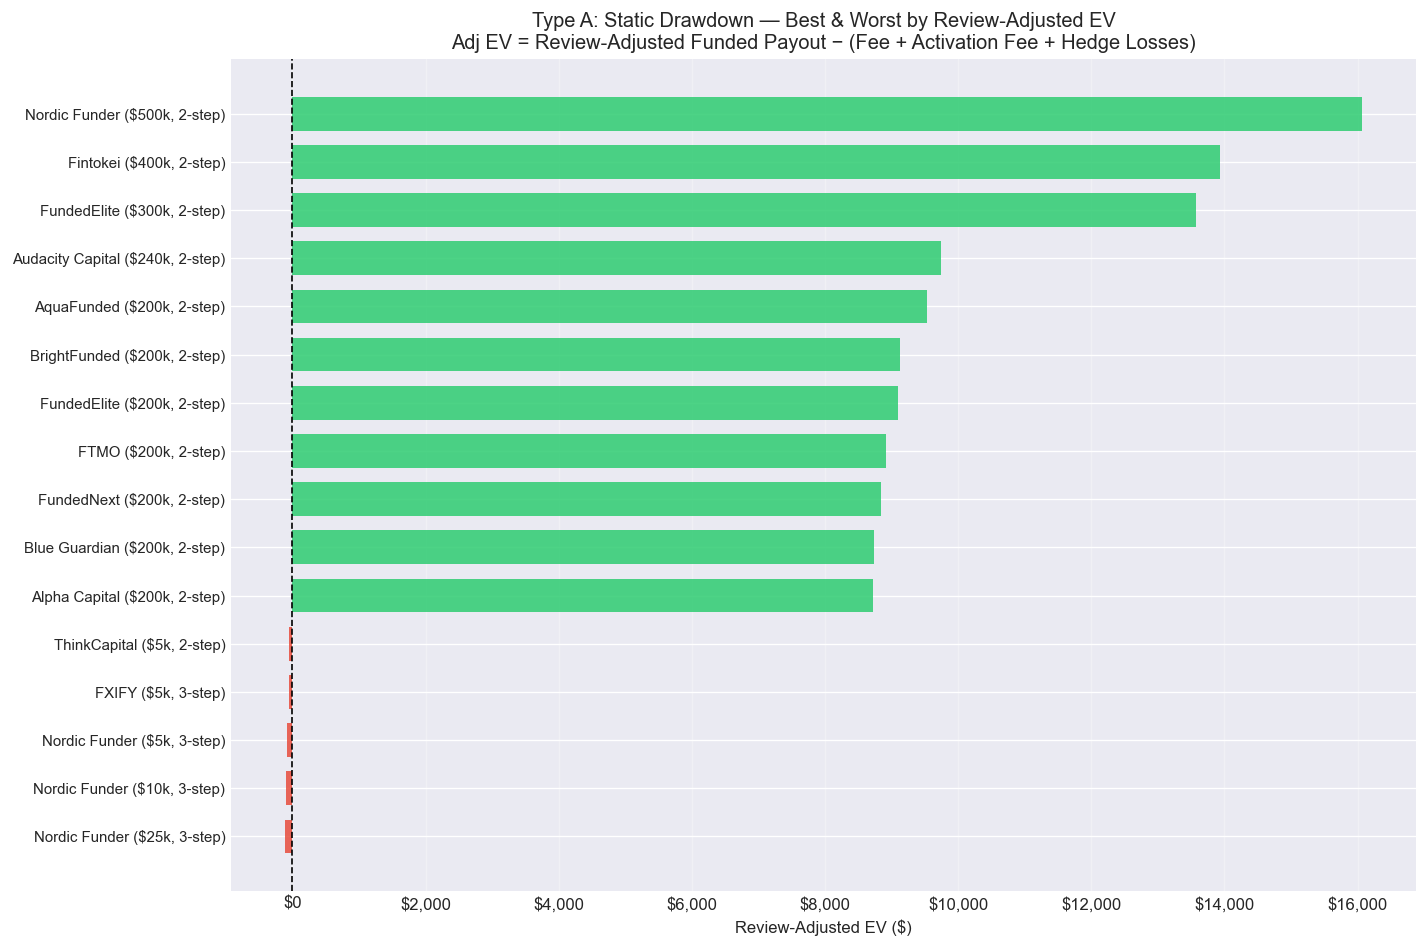

In [11]:
df_sorted = df.sort_values('EV_review_adj', ascending=False)
df_show = pd.concat([df_sorted.head(15), df_sorted.tail(5)]).drop_duplicates(
    subset=['firm', 'account_size']).sort_values('EV_review_adj', ascending=True).copy()
df_show['label'] = df_show.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k, {r['steps']}-step)", axis=1)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_show['EV_review_adj']]
ax.barh(range(len(df_show)), df_show['EV_review_adj'], color=colors, alpha=0.85, height=0.7)
ax.set_yticks(range(len(df_show)))
ax.set_yticklabels(df_show['label'], fontsize=9)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Review-Adjusted EV ($)')
ax.set_title('Type A: Static Drawdown — Best & Worst by Review-Adjusted EV\n'
             'Adj EV = Review-Adjusted Funded Payout − (Fee + Activation Fee + Hedge Losses)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Phase-by-Phase Cost Growth

How your costs stack up through each challenge phase. The cost starts with the challenge fee, then each phase adds the hedge loss on top.

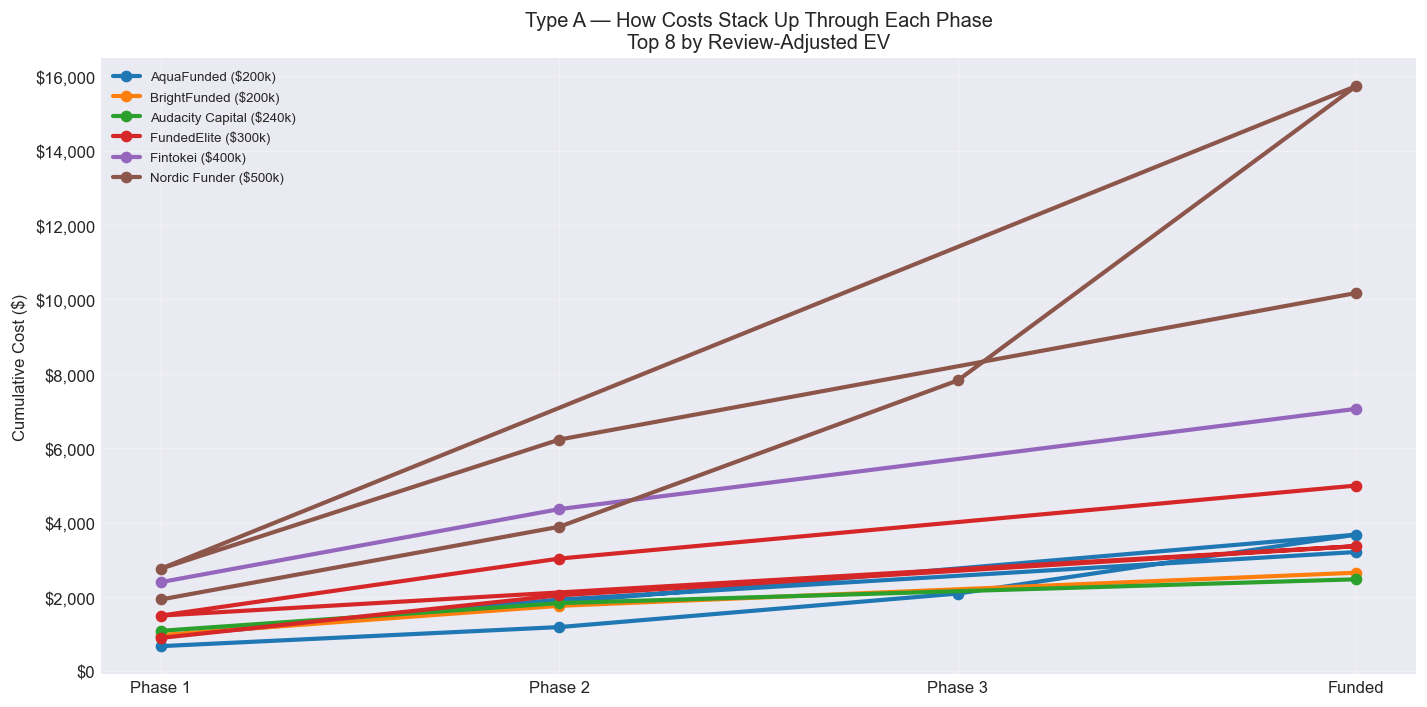

In [12]:
top8 = df.nlargest(8, 'EV_review_adj')
top_keys = set(zip(top8['firm'], top8['account_size']))

rows_ph = []
for r in results:
    if (r['firm'], r['account_size']) not in top_keys:
        continue
    label = f"{r['firm']} (${r['account_size']/1000:.0f}k)"
    for ph in r['phases']:
        rows_ph.append({'label': label, 'phase': f"Phase {ph['phase']}", 'cost': ph['cost_before']})
    rows_ph.append({'label': label, 'phase': 'Funded', 'cost': r['total_cost']})

df_ph = pd.DataFrame(rows_ph)

fig, ax = plt.subplots(figsize=(12, 6))
cm = plt.cm.tab10.colors
for i, label in enumerate(df_ph['label'].unique()):
    sub = df_ph[df_ph['label'] == label]
    ax.plot(sub['phase'], sub['cost'], marker='o', linewidth=2.5, color=cm[i % 10], label=label)

ax.set_ylabel('Cumulative Cost ($)')
ax.set_title('Type A — How Costs Stack Up Through Each Phase\nTop 8 by Review-Adjusted EV')
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Funded Target Sensitivity

How does EV change as you vary the funded profit target? Lower = safer but less profit. Higher = more profit but takes longer and more risk.

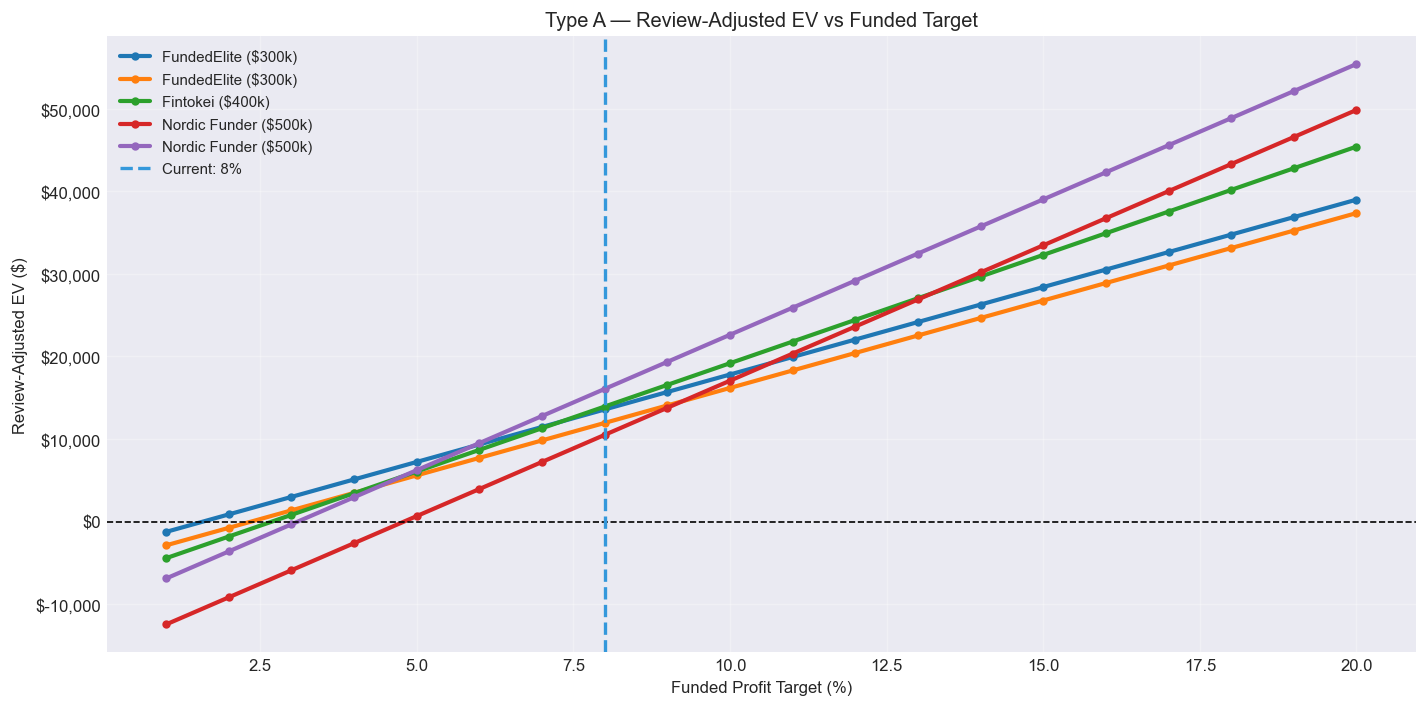

In [13]:
top5 = df.nlargest(5, 'EV_review_adj')
top5_keys = set(zip(top5['firm'], top5['account_size']))
top5_chs = [c for c in challenges if (c.get('firm'), c.get('account_size')) in top5_keys]

fig, ax = plt.subplots(figsize=(12, 6))
sweep = [p / 100 for p in range(1, 21)]
cm = plt.cm.tab10.colors

for i, ch in enumerate(top5_chs[:5]):
    review_factor = float(
        df.loc[
            (df['firm'] == ch['firm']) & (df['account_size'] == ch['account_size']),
            'review_factor',
        ].iloc[0]
    )
    sweep_results = [compute_type_a(ch, funded_target=t) for t in sweep]
    evs_adj = [round(r['funded_payout'] * review_factor - r['total_cost'], 2) for r in sweep_results]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot([t * 100 for t in sweep], evs_adj, marker='o', markersize=4,
            linewidth=2.5, color=cm[i % 10], label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.axvline(FUNDED_TARGET * 100, color='#3498db', linestyle='--', linewidth=2,
           label=f'Current: {FUNDED_TARGET*100:.0f}%')
ax.set_xlabel('Funded Profit Target (%)')
ax.set_ylabel('Review-Adjusted EV ($)')
ax.set_title('Type A — Review-Adjusted EV vs Funded Target')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Capital Efficiency

Which challenges give you the most EV per dollar of capital you need on your personal broker?

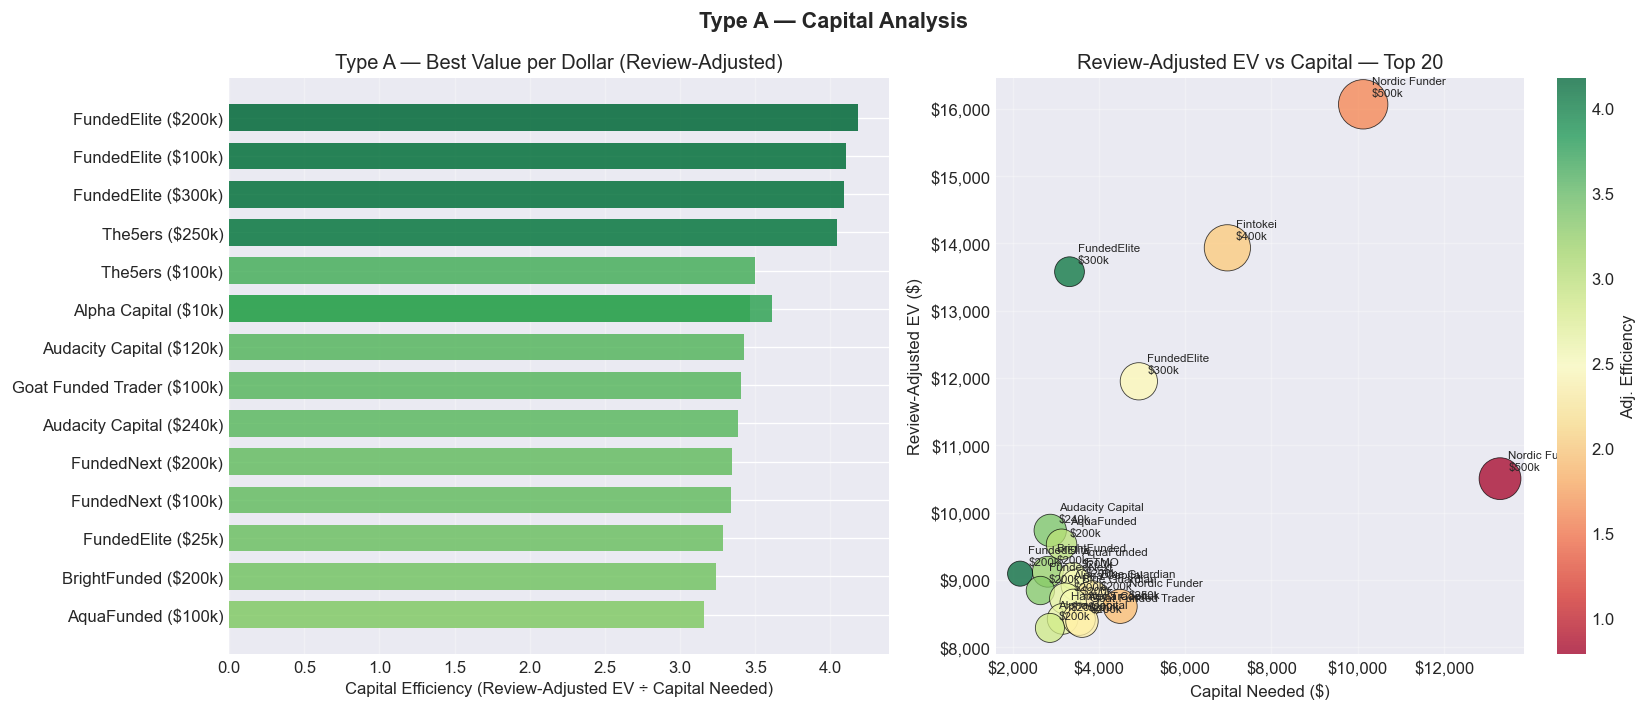

In [14]:
df_cap = df[df['capital_efficiency_review_adj'] > 0].nlargest(15, 'capital_efficiency_review_adj').sort_values(
    'capital_efficiency_review_adj', ascending=True).copy()
df_cap['label'] = df_cap.apply(lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
cmap = plt.cm.RdYlGn([
    v / df_cap['capital_efficiency_review_adj'].max() for v in df_cap['capital_efficiency_review_adj']
])
ax1.barh(df_cap['label'], df_cap['capital_efficiency_review_adj'], color=cmap, alpha=0.85, height=0.7)
ax1.set_xlabel('Capital Efficiency (Review-Adjusted EV ÷ Capital Needed)')
ax1.set_title('Type A — Best Value per Dollar (Review-Adjusted)')
ax1.grid(axis='x', alpha=0.3)

top20 = df.nlargest(20, 'EV_review_adj')
sc = ax2.scatter(top20['capital_needed'], top20['EV_review_adj'], s=top20['fee'] * 0.3 + 50, alpha=0.75,
                 c=top20['capital_efficiency_review_adj'], cmap='RdYlGn', edgecolors='black', linewidth=0.5)
for _, r in top20.iterrows():
    ax2.annotate(f"{r['firm']}\n${r['account_size']/1000:.0f}k",
                 (r['capital_needed'], r['EV_review_adj']), textcoords='offset points', xytext=(5, 5), fontsize=7)
ax2.set_xlabel('Capital Needed ($)')
ax2.set_ylabel('Review-Adjusted EV ($)')
ax2.set_title('Review-Adjusted EV vs Capital — Top 20')
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)
plt.colorbar(sc, ax=ax2, label='Adj. Efficiency')
plt.suptitle('Type A — Capital Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

### What Type A means for you
- **Simplest hedge model.** You insure through the challenge phases and stop.
- Static drawdown makes life easy — the floor doesn't move, so your hedge size stays constant per phase.
- Fewer steps = less cost stacking = better EV.
- Activation fees (paid when funded) are included in total cost.

### Best for
- First-time hedgers wanting the simplest approach
- Challenges where the first funded payout clearly covers costs
- Limited capital — you only fund the challenge hedge

### What it doesn't cover
- What happens after the first payout (see a funded continuation model)
- Trailing drawdown challenges (see **Type B**)
- Instant funded accounts (see **Type C**)